In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

ZIP_PATH     = "/content/drive/MyDrive/MLPR.zip"
EXTRACT_PATH = "/content/dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

if not os.path.exists("/content/dataset/MLPR"):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_PATH)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

DATASET_PATH = "/content/dataset/MLPR/Final Dataset/Rice Leaf Disease Images/Rice Leaf Disease Images"
print(f"\nChecking dataset path...")
if os.path.exists(DATASET_PATH):
    classes = os.listdir(DATASET_PATH)
    print(f"Found classes: {sorted(classes)}")
else:
    print("ERROR — path not found, check extraction")

Mounted at /content/drive
Extracting dataset...
Extraction complete.

Checking dataset path...
Found classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro', 'normal']


In [3]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops, hog, local_binary_pattern

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix)

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

print("TF     :", tf.__version__)
print("OpenCV :", cv2.__version__)
print("GPU    :", tf.config.list_physical_devices('GPU') or "None — CPU mode")

TF     : 2.20.0
OpenCV : 4.13.0
GPU    : None — CPU mode


In [4]:
def preprocess(img_bgr, size=128):

    lab     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l       = clahe.apply(l)
    img     = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

    img = cv2.resize(img, (size, size))
    return img

print("Preprocessing: CLAHE + Resize")
print("No GrabCut needed — dataset has no domain bias")

Preprocessing: CLAHE + Resize
No GrabCut needed — dataset has no domain bias


In [5]:
DATASET_PATH = "/content/dataset/MLPR/Final Dataset/Rice Leaf Disease Images/Rice Leaf Disease Images"
IMG_SIZE     = 128
valid_ext    = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

images_list, labels_list = [], []

print("Loading images...")
for cls_folder in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls_folder)
    if not os.path.isdir(cls_path):
        continue

    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith(valid_ext)]

    for file in files:
        path = os.path.join(cls_path, file)
        img  = cv2.imread(path)
        if img is None:
            continue

        img = preprocess(img, IMG_SIZE)
        images_list.append(img)
        labels_list.append(cls_folder)

images = np.array(images_list)
labels = np.array(labels_list)

print(f"Total images loaded : {images.shape[0]}")
print(f"Image shape         : {images.shape[1:]}")
print(f"\nClass distribution:")
for k, v in sorted(Counter(labels).items()):
    print(f"  {k:20s}: {v}")

# Brightness check — confirm all classes are similar
print(f"\nBrightness check (all should be in similar range):")
for cls in np.unique(labels):
    m = images[labels == cls].mean()
    s = images[labels == cls].std()
    print(f"  {cls:20s}: mean={m:.1f}  std={s:.1f}")

Loading images...
Total images loaded : 7696
Image shape         : (128, 128, 3)

Class distribution:
  Bacterialblight     : 1584
  Blast               : 1440
  Brownspot           : 1600
  Tungro              : 1308
  normal              : 1764

Brightness check (all should be in similar range):
  Bacterialblight     : mean=105.0  std=64.3
  Blast               : mean=109.1  std=57.6
  Brownspot           : mean=112.0  std=54.1
  Tungro              : mean=114.1  std=51.3
  normal              : mean=104.4  std=73.6


In [6]:
le = LabelEncoder()
y  = le.fit_transform(labels)

print("Classes and their encoded values:")
for i, cls in enumerate(le.classes_):
    count = np.sum(y == i)
    print(f"  {i} = {cls:20s} ({count} images)")

# SPLIT FIRST — 70% train, 10% val, 20% test
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    images, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train_raw, X_val_raw, y_train_raw, y_val = train_test_split(
    X_train_raw, y_train_raw,
    test_size=0.125,   # 0.125 of 80% = 10% of total
    stratify=y_train_raw,
    random_state=42
)

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train_raw):>5}  ({len(X_train_raw)/len(images)*100:.1f}%)")
print(f"  Val   : {len(X_val_raw):>5}  ({len(X_val_raw)/len(images)*100:.1f}%)")
print(f"  Test  : {len(X_test_raw):>5}  ({len(X_test_raw)/len(images)*100:.1f}%)")
print(f"  Total : {len(images):>5}")

# Confirm class balance in each split
print(f"\nClass distribution in each split:")
print(f"{'Class':20s} {'Train':>8} {'Val':>6} {'Test':>6}")
print("-" * 44)
for i, cls in enumerate(le.classes_):
    tr = np.sum(y_train_raw == i)
    vl = np.sum(y_val == i)
    te = np.sum(y_test == i)
    print(f"  {cls:20s} {tr:>6}   {vl:>4}   {te:>4}")

Classes and their encoded values:
  0 = Bacterialblight      (1584 images)
  1 = Blast                (1440 images)
  2 = Brownspot            (1600 images)
  3 = Tungro               (1308 images)
  4 = normal               (1764 images)

Split sizes:
  Train :  5386  (70.0%)
  Val   :   770  (10.0%)
  Test  :  1540  (20.0%)
  Total :  7696

Class distribution in each split:
Class                   Train    Val   Test
--------------------------------------------
  Bacterialblight        1109    158    317
  Blast                  1008    144    288
  Brownspot              1120    160    320
  Tungro                  915    131    262
  normal                 1234    177    353


In [7]:
base = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet',
    alpha=0.35
)
base.trainable = False   # frozen — no training at all

early_layer       = base.get_layer('block_3_expand_relu')
feature_extractor = tf.keras.Model(
    inputs=base.input,
    outputs=tf.keras.layers.GlobalAveragePooling2D()(early_layer.output)
)

print(f"Feature extractor output dim : {feature_extractor.output_shape[1]}")
print(f"Total params (all frozen)    : {base.count_params():,}")
print("No training — pure forward pass only")

2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature extractor output dim : 48
Total params (all frozen)    : 410,208
No training — pure forward pass only


In [8]:
def extract_glcm(grey):
    """Texture — first to change at onset of disease"""
    glcm = graycomatrix(grey, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    feats = []
    for prop in ['contrast', 'energy', 'homogeneity', 'correlation']:
        feats.extend(graycoprops(glcm, prop).flatten())
    return feats  # 16 values

def extract_lbp(grey):
    """Local Binary Pattern — captures micro texture at lesion boundary"""
    lbp       = local_binary_pattern(grey, P=8, R=1, method='uniform')
    hist, _   = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    hist      = hist.astype(float)
    hist     /= (hist.sum() + 1e-6)
    return hist.tolist()  # 10 values

def extract_hog_features(grey):
    """Shape — lesion morphology is unique per disease"""
    return hog(grey, orientations=8,
               pixels_per_cell=(16, 16),
               cells_per_block=(1, 1),
               visualize=False).tolist()

def extract_colour_moments(hsv):
    """
    Colour moments on HSV.
    Green % difference IS a real disease signal here —
    diseased leaves lose chlorophyll (green tissue)
    """
    feats = []
    for i in range(3):
        ch   = hsv[:, :, i].astype(float)
        mean = np.mean(ch)
        std  = np.std(ch)
        skew = np.mean(((ch - mean) / (std + 1e-6)) ** 3)
        feats.extend([mean, std, skew])
    return feats  # 9 values

def extract_deep(img_bgr):
    """Frozen MobileNetV2 spatial features — no GPU needed"""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_f   = img_rgb.astype(np.float32) / 255.0
    return feature_extractor.predict(
        np.expand_dims(img_f, 0), verbose=0)[0]

def extract_all(img_bgr):
    """
    Full feature vector:
    Deep(24) + GLCM(16) + LBP(10) + HOG(~512) + Colour(9) = ~571
    """
    grey = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    return np.hstack([
        extract_deep(img_bgr),
        extract_glcm(grey),
        extract_lbp(grey),
        extract_hog_features(grey),
        extract_colour_moments(hsv)
    ])

test_f = extract_all(X_train_raw[0])
print(f"Feature vector dim : {test_f.shape[0]}")
print(f"Breakdown          : Deep(24) + GLCM(16) + LBP(10) + HOG(~512) + Colour(9)")

Feature vector dim : 595
Breakdown          : Deep(24) + GLCM(16) + LBP(10) + HOG(~512) + Colour(9)


In [9]:
def augment_image(img_bgr):
    """
    Conservative augmentation — only geometric transforms.
    No brightness changes since CLAHE already normalised contrast.
    Applied ONLY to training data AFTER split.
    """
    img = img_bgr.copy()

    # horizontal flip
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 1)

    # vertical flip
    if np.random.rand() > 0.5:
        img = cv2.flip(img, 0)

    # small rotation -15 to +15 degrees
    if np.random.rand() > 0.5:
        h, w  = img.shape[:2]
        angle = np.random.uniform(-15, 15)
        M     = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img   = cv2.warpAffine(img, M, (w, h),
                               borderMode=cv2.BORDER_REFLECT)

    # small zoom/crop
    if np.random.rand() > 0.5:
        h, w  = img.shape[:2]
        scale = np.random.uniform(0.85, 1.0)
        nh, nw = int(h*scale), int(w*scale)
        y1 = (h - nh) // 2
        x1 = (w - nw) // 2
        img = img[y1:y1+nh, x1:x1+nw]
        img = cv2.resize(img, (w, h))

    return img

print("Augmentation: flip + rotation + zoom (geometry only)")
print("Applied ONLY to training data — val and test stay clean")

Augmentation: flip + rotation + zoom (geometry only)
Applied ONLY to training data — val and test stay clean


In [10]:
print("Extracting features — train (with augmentation)...")
print("Expected time: ~12-18 min on CPU\n")

# TRAINING — original + 1 augmented copy per image
X_train_feats, y_train_aug = [], []
for img, lbl in tqdm(zip(X_train_raw, y_train_raw),
                     total=len(X_train_raw),
                     desc="Train"):
    X_train_feats.append(extract_all(img))
    y_train_aug.append(lbl)
    X_train_feats.append(extract_all(augment_image(img)))
    y_train_aug.append(lbl)

X_train_feats = np.array(X_train_feats)
y_train_aug   = np.array(y_train_aug)

# VALIDATION — no augmentation
print("\nExtracting val features...")
X_val_feats = np.array([
    extract_all(img) for img in tqdm(X_val_raw, desc="Val")
])

# TEST — no augmentation
print("\nExtracting test features...")
X_test_feats = np.array([
    extract_all(img) for img in tqdm(X_test_raw, desc="Test")
])

print(f"\nTrain samples : {X_train_feats.shape[0]}  (original + 1 aug copy)")
print(f"Val   samples : {X_val_feats.shape[0]}   (clean)")
print(f"Test  samples : {X_test_feats.shape[0]}  (clean)")
print(f"Feature dim   : {X_train_feats.shape[1]}")

Extracting features — train (with augmentation)...
Expected time: ~12-18 min on CPU



Train: 100%|██████████| 5386/5386 [25:02<00:00,  3.58it/s]



Extracting val features...


Val: 100%|██████████| 770/770 [01:55<00:00,  6.68it/s]



Extracting test features...


Test: 100%|██████████| 1540/1540 [03:41<00:00,  6.95it/s]


Train samples : 10772  (original + 1 aug copy)
Val   samples : 770   (clean)
Test  samples : 1540  (clean)
Feature dim   : 595


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feats)  # fit on train only
X_val_scaled   = scaler.transform(X_val_feats)         # transform val
X_test_scaled  = scaler.transform(X_test_feats)        # transform test

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)  # fit on train only
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Features before PCA : {X_train_scaled.shape[1]}")
print(f"Features after  PCA : {X_train_pca.shape[1]}")
print(f"Variance retained   : 95%")
print(f"Scaler and PCA fitted on training data only — no leakage")

Features before PCA : 595
Features after  PCA : 326
Variance retained   : 95%
Scaler and PCA fitted on training data only — no leakage


In [19]:
# Train Random Forest on full training data
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    bootstrap = True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_pca, y_train_aug)

y_pred    = rf.predict(X_test_pca)
train_acc = accuracy_score(y_train_aug, rf.predict(X_train_pca))
val_acc   = accuracy_score(y_val,       rf.predict(X_val_pca))
test_acc  = accuracy_score(y_test,      y_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Val   Accuracy : {val_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Train-Test Gap : {train_acc - test_acc:.4f}",
      "← good" if train_acc - test_acc < 0.10 else "← overfitting")

print()
print(classification_report(y_test, y_pred,
                             target_names=le.classes_))

Train Accuracy : 0.9581
Val   Accuracy : 0.9286
Test  Accuracy : 0.9188
Train-Test Gap : 0.0393 ← good

                 precision    recall  f1-score   support

Bacterialblight       0.90      0.85      0.87       317
          Blast       0.93      0.92      0.92       288
      Brownspot       0.93      0.89      0.91       320
         Tungro       0.92      0.94      0.93       262
         normal       0.92      1.00      0.96       353

       accuracy                           0.92      1540
      macro avg       0.92      0.92      0.92      1540
   weighted avg       0.92      0.92      0.92      1540



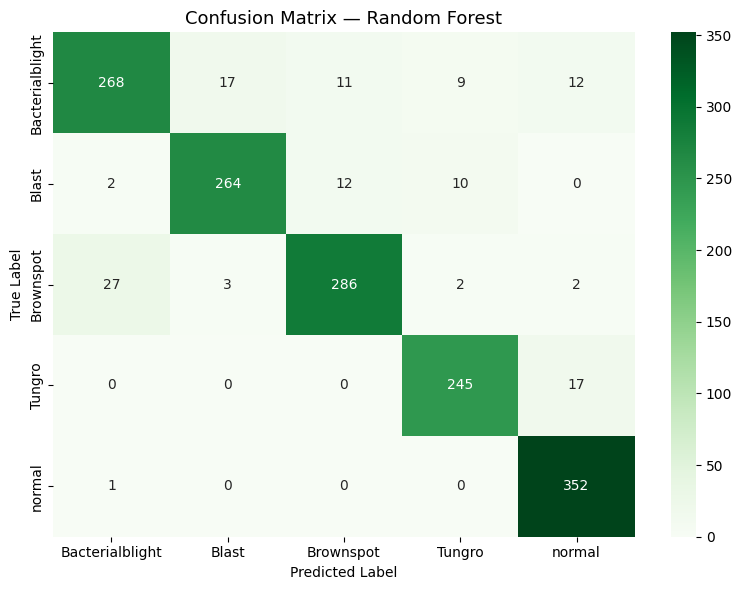


Per-class accuracy:
  Bacterialblight     : 0.845
  Blast               : 0.917
  Brownspot           : 0.894
  Tungro              : 0.935
  normal              : 0.997


In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Per class accuracy
print("\nPer-class accuracy:")
for i, cls in enumerate(le.classes_):
    cls_mask = y_test == i
    cls_acc  = accuracy_score(y_test[cls_mask], y_pred[cls_mask])
    print(f"  {cls:20s}: {cls_acc:.3f}")

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Performance Metrics\n")

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nDetailed Classification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Performance Metrics

Accuracy  : 0.9188
Precision : 0.9187
Recall    : 0.9188
F1-Score  : 0.9181

Detailed Classification Report:

                 precision    recall  f1-score   support

Bacterialblight       0.90      0.85      0.87       317
          Blast       0.93      0.92      0.92       288
      Brownspot       0.93      0.89      0.91       320
         Tungro       0.92      0.94      0.93       262
         normal       0.92      1.00      0.96       353

       accuracy                           0.92      1540
      macro avg       0.92      0.92      0.92      1540
   weighted avg       0.92      0.92      0.92      1540



In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

pipeline = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        bootstrap=True,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X_train_feats,
    y_train_aug,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("CV accuracy:", scores)
print("Mean CV:", scores.mean())
print("Std CV:", scores.std())

CV accuracy: [0.94895592 0.94153132 0.95589601 0.95543175 0.95218199]
Mean CV: 0.950799397656548
Std CV: 0.005265764098913196


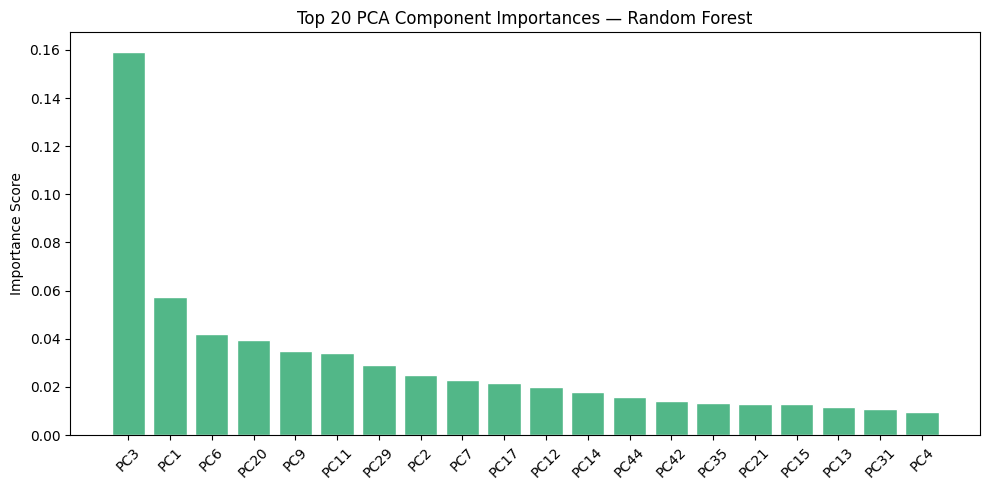

Feature group contributions:
  Deep (MobileNet) : 0.561
  GLCM (Texture)   : 0.116
  LBP  (Texture)   : 0.064
  HOG  (Shape)     : 0.256
  Colour Moments   : 0.003


In [25]:
importances = rf.feature_importances_
top_idx     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10, 5))
plt.bar(range(20), importances[top_idx],
        color='#52B788', edgecolor='white')
plt.xticks(range(20), [f'PC{i+1}' for i in top_idx], rotation=45)
plt.title('Top 20 PCA Component Importances — Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# Overall importance by feature group
deep_imp   = rf.feature_importances_[:24].sum()
glcm_imp   = rf.feature_importances_[24:40].sum()
lbp_imp    = rf.feature_importances_[40:50].sum()
hog_imp    = rf.feature_importances_[50:-9].sum()
colour_imp = rf.feature_importances_[-9:].sum()

print("Feature group contributions:")
print(f"  Deep (MobileNet) : {deep_imp:.3f}")
print(f"  GLCM (Texture)   : {glcm_imp:.3f}")
print(f"  LBP  (Texture)   : {lbp_imp:.3f}")
print(f"  HOG  (Shape)     : {hog_imp:.3f}")
print(f"  Colour Moments   : {colour_imp:.3f}")

In [31]:
def estimate_severity(img_bgr):

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    green = cv2.inRange(
        hsv,
        np.array([30, 40, 40]),
        np.array([95, 255, 255])
    )

    brown = cv2.inRange(
        hsv,
        np.array([8, 70, 50]),
        np.array([20, 255, 170])
    )

    yellow = cv2.inRange(
        hsv,
        np.array([20, 90, 90]),
        np.array([35, 255, 255])
    )

    diseased = cv2.bitwise_or(brown, yellow)

    green_pixels = np.sum(green > 0)
    disease_pixels = np.sum(diseased > 0)

    total = green_pixels + disease_pixels

    if total == 0:
        return "Unknown", 0.0

    severity = (disease_pixels / total) * 100

    if severity < 4:
        stage = "Healthy / Very Early"
    elif severity < 12:
        stage = "Early Stage"
    elif severity < 30:
        stage = "Mid Stage"
    else:
        stage = "Advanced Stage"

    return stage, severity

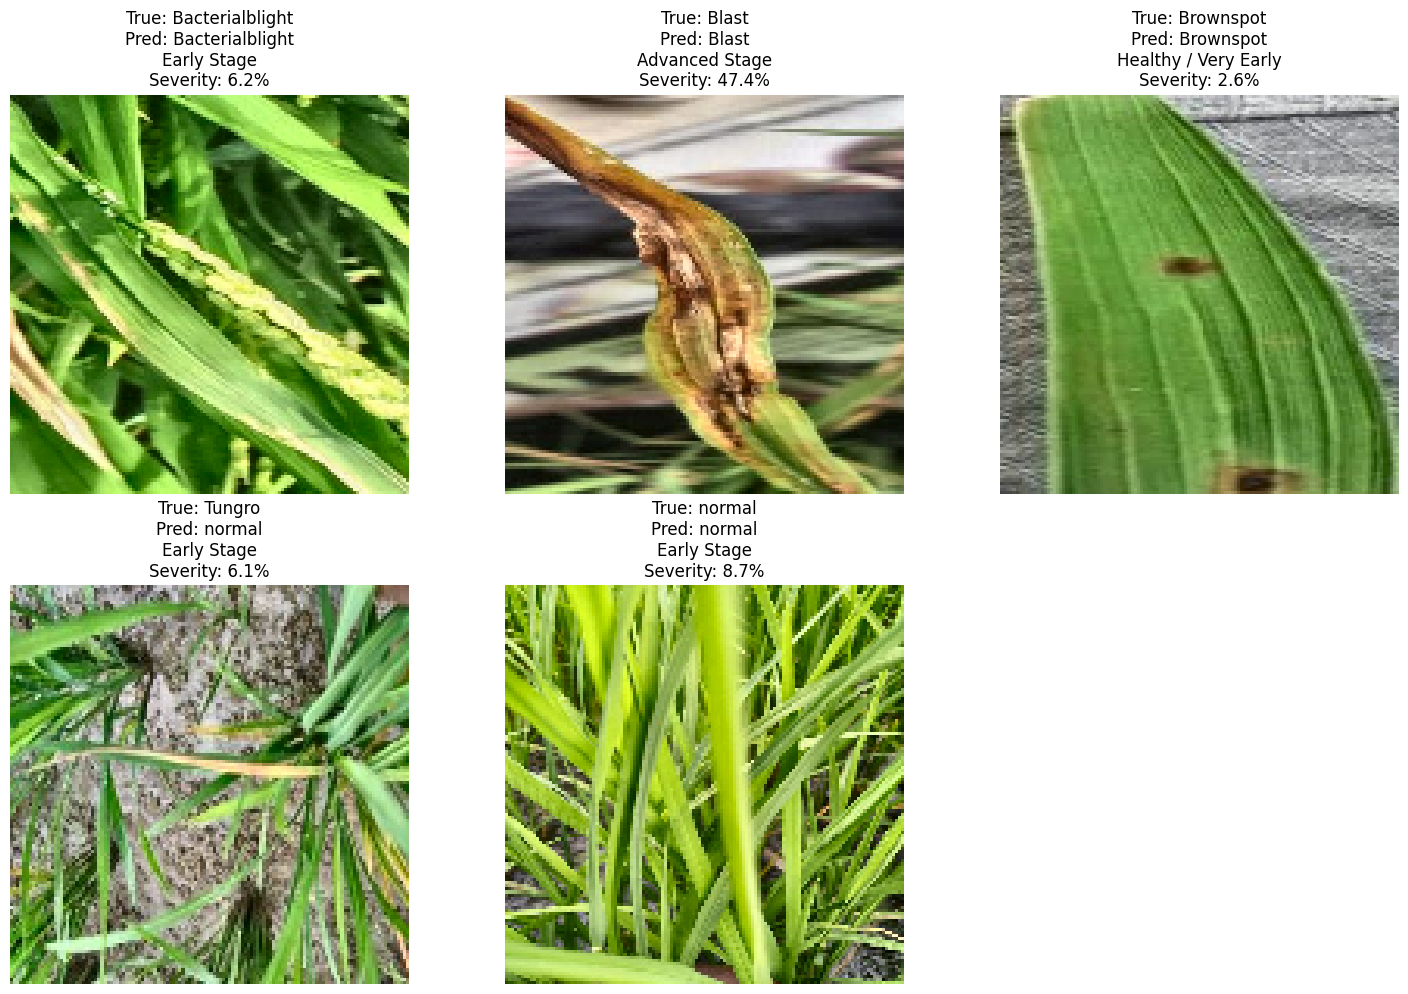

In [32]:
plt.figure(figsize=(15,10))

for i, cls_idx in enumerate(np.unique(y_test)):

    idx = np.where(y_test == cls_idx)[0][0]

    img = X_test_raw[idx]

    stage, severity = estimate_severity(img)

    feats = extract_all(preprocess(img, IMG_SIZE))
    feats_pca = pca.transform(scaler.transform([feats]))

    pred = rf.predict(feats_pca)[0]
    disease = le.classes_[pred]

    plt.subplot(2,3,i+1)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)

    plt.title(
        f"True: {le.classes_[cls_idx]}\n"
        f"Pred: {disease}\n"
        f"{stage}\n"
        f"Severity: {severity:.1f}%"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()